In [2]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [31]:
power_law_db = pl.read_parquet(
    r"MLE_random_sample_fit_data\PowerLaw").filter(
        pl.col("min_alpha_to_consider") == 1e2)

weibull_db = pl.read_parquet(
    r"MLE_random_sample_fit_data\Weibull").filter(
            pl.col("min_alpha_to_consider") == 1e2)

log_normal_db = pl.read_parquet(
    r"MLE_random_sample_fit_data\LogNormal").filter(
            pl.col("min_alpha_to_consider") == 1e2, pl.col("mu") > -100)

In [27]:
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

numb_bootstrap = 20

seed_vals_to_run: np.ndarray = np.random.random_integers(
            0, 100_000, size=numb_bootstrap)

alphas_hist = np.geomspace(1, 1e6, 50)
alphas = np.geomspace(100, 1e6, 100)

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)

C:\Users\Joshu\AppData\Local\Temp\ipykernel_34268\712144320.py:5: DeprecationWarning: This function is deprecated. Please call randint(0, 100000 + 1) instead
  seed_vals_to_run: np.ndarray = np.random.random_integers(


In [28]:
from boulder_statistics.analysis.log_normal_fitting import LogNormalFitting
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams

mus = log_normal_db["mu"].to_numpy()
sigmas = log_normal_db["sigma"].to_numpy()

mu = np.median(mus)
sigma = np.median(sigmas)

LN_fit_params = LogNormalFitParams(mu=mu, sigma=sigma)

LN_fit = LogNormalFitting(
    dp,
    LAD_min=0,
    sensitivity_model=sm,
    min_alpha_to_consider=100
)

print(f"mu = {mus.mean()} ± {mus.std()}")
print(f"sigma = {sigmas.mean()} ± {sigmas.std()}")

mu = -20.64452679537524 ± 14.632184345483406
sigma = 4.217001674126078 ± 1.2766533049922926


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  1.,
         1.,  0.,  0.,  1.,  0.,  0.,  3.,  2.,  2.,  0.,  2.,  2.,  0.,
         2.,  1.,  1.,  1.,  0.,  5.,  1.,  4.,  7.,  2.,  5.,  4.,  2.,
         6., 16.,  7.,  2.,  2.,  6.,  5.,  5.,  3.]),
 array([-92.18685179, -91.32900508, -90.47115838, -89.61331168,
        -88.75546498, -87.89761828, -87.03977158, -86.18192487,
        -85.32407817, -84.46623147, -83.60838477, -82.75053807,
        -81.89269136, -81.03484466, -80.17699796, -79.31915126,
        -78.46130456, -77.60345785, -76.74561115, -75.88776445,
        -75.02991775, -74.17207105, -73.31422435, -72.45637764,
        -71.59853094, -70.74068424, -69.88283754, 

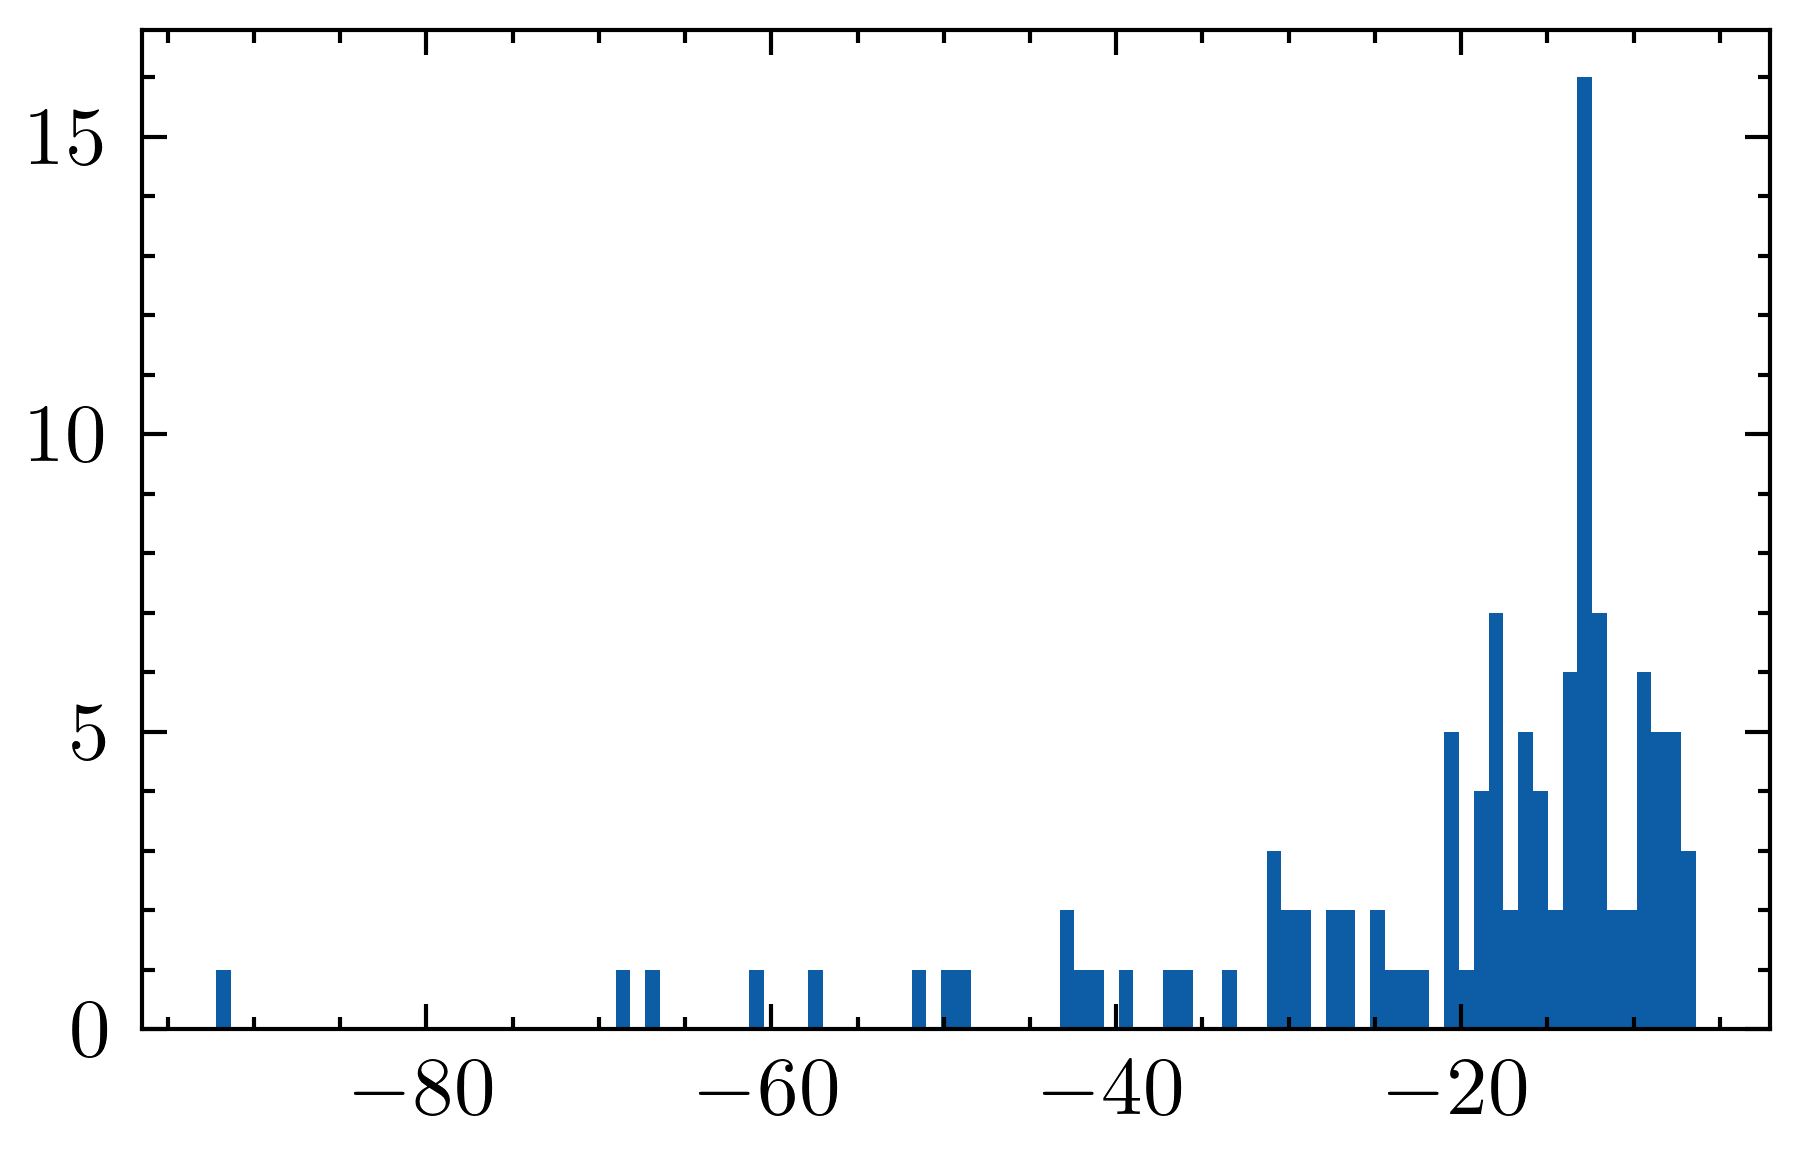

In [29]:
plt.hist(mus, 100)

In [19]:
from boulder_statistics.analysis.weibull_fitting import WeibullFitting
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

lambdas = weibull_db["lambda"].to_numpy()
ks = weibull_db["k"].to_numpy()

lambda_ = np.median(lambdas)
k = np.median(ks)

W_fit_params = WeibullFitParams(lambda_=lambda_, k=k)
W_fit = WeibullFitting(
    dp,
    LAD_min=0,
    sensitivity_model=sm,
    min_alpha_to_consider=100
)

print(f"lambda = {lambdas.mean()} ± {lambdas.std()}")
print(f"k = {ks.mean()} ± {ks.std()}")

lambda = 4.713062341702818e-12 ± 8.386727963422538e-12
k = 0.07758178998479744 ± 0.01251692463475136


In [32]:
from boulder_statistics.analysis.power_law_var_g_fitting import PowerLawVarGFitting
from boulder_statistics.analysis.fit_params.power_law_var_g_fit_params import PowerLawVarGFitParams

qs = power_law_db["q"].to_numpy()
g_mus = power_law_db["g_mu"].to_numpy()
g_stds = power_law_db["g_std"].to_numpy()

q = np.median(qs)
g_mu = np.median(g_mus)
g_std = np.median(g_stds)

PL_fit_params = PowerLawVarGFitParams(q, g_mu, g_std)

PL_fit = PowerLawVarGFitting(
    dp,
    LAD_min=0,
    sensitivity_model=sm,
    min_alpha_to_consider=100
)

print(f"q = {- qs.mean() * 2} ± {- qs.std() * 2}")
print(f"g_mu = {g_mus.mean()} ± {g_mus.std()}")
print(f"g_std = {g_stds.mean()} ± {g_stds.std()}")

q = -2.1113844956815337 ± -0.06695236468649028
g_mu = 0.4480123130004006 ± 0.02438687393287137
g_std = 0.07597852032782235 ± 0.0019417848718780314


Computing F_norm:  60%|██████    | 12/20 [00:01<00:01,  6.52it/s]


KeyboardInterrupt: 

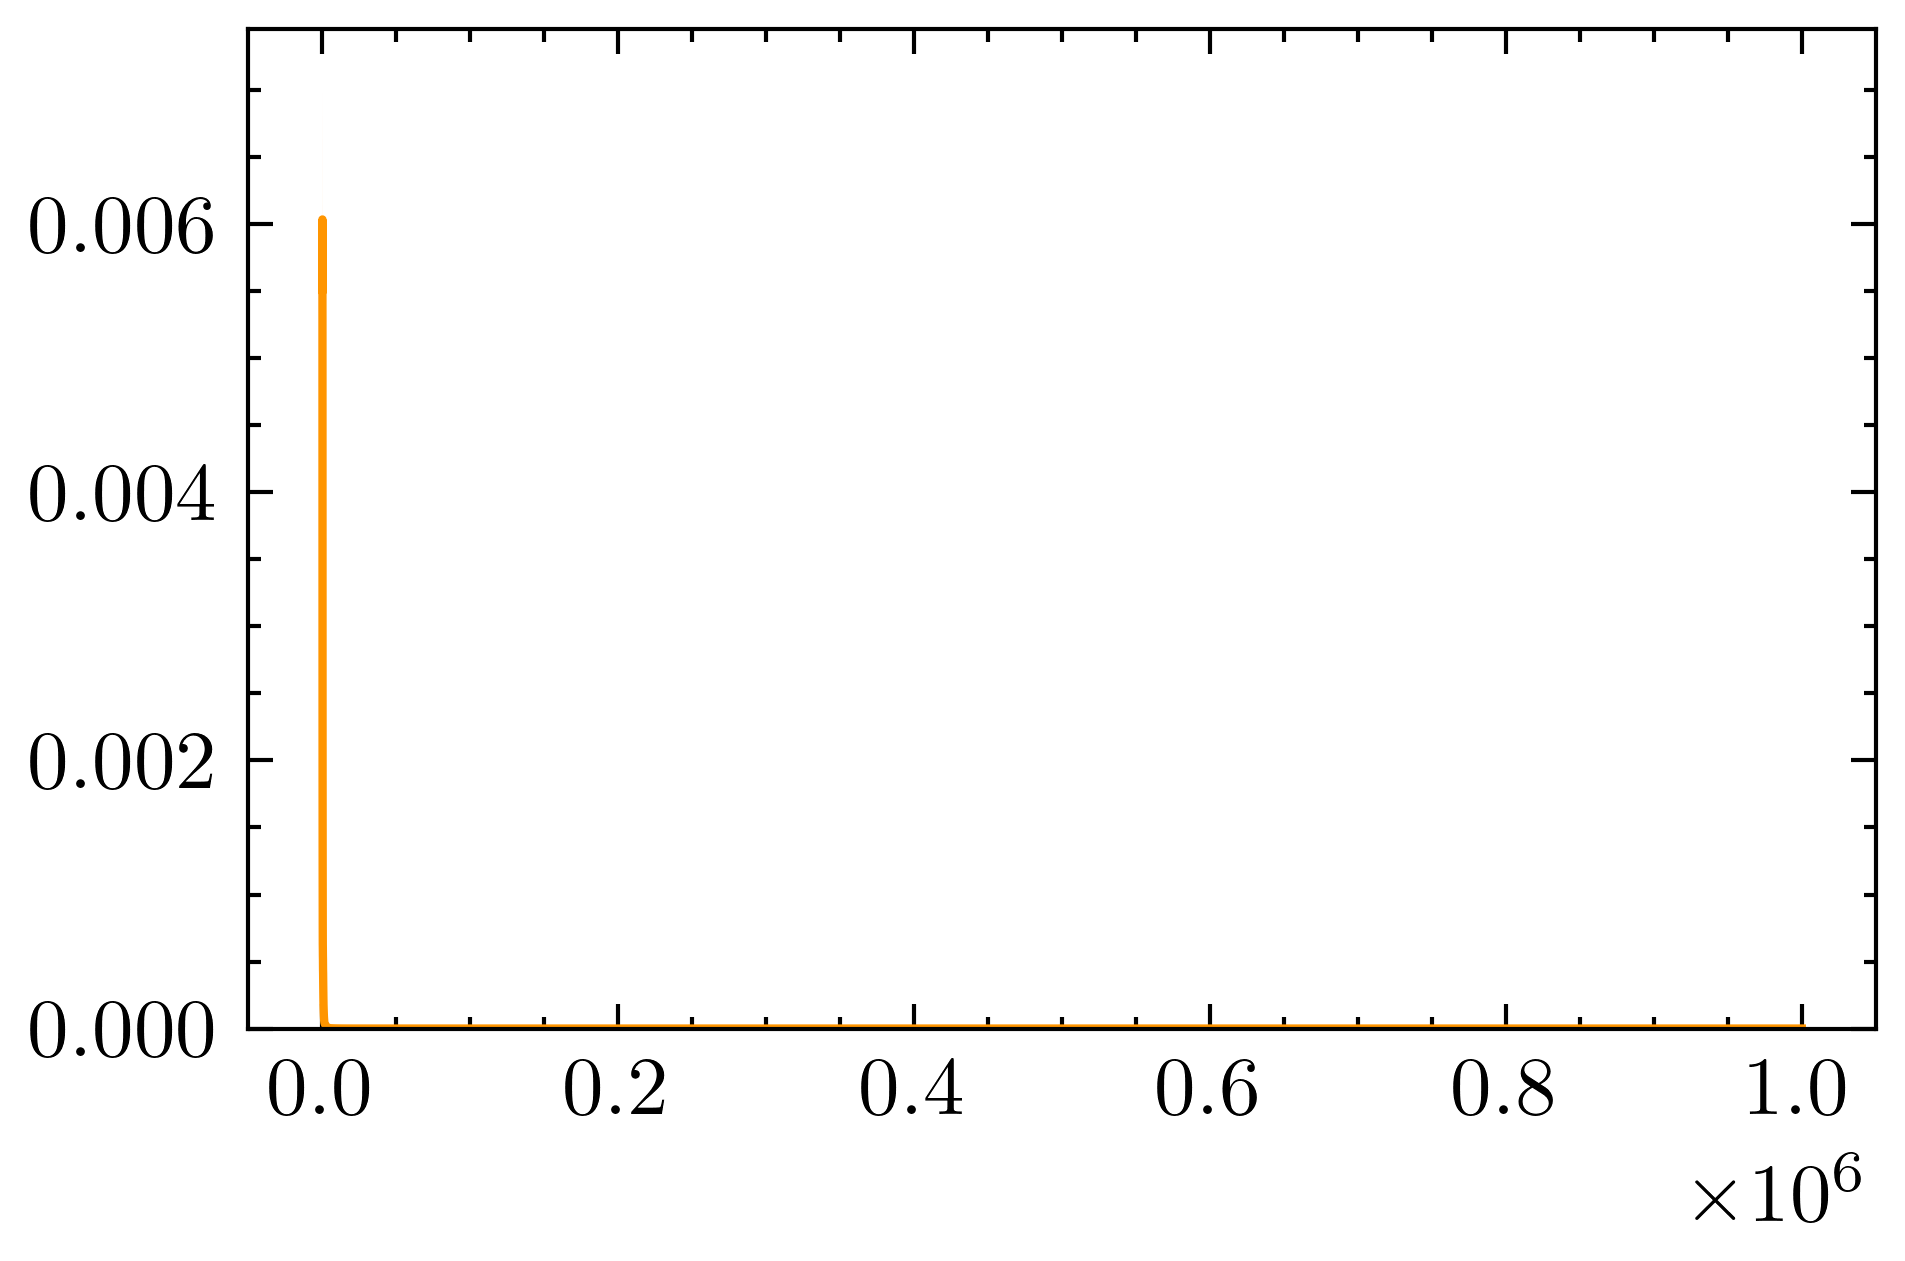

In [21]:
from tqdm import tqdm

counts, bins, _ = plt.hist(LN_fit.cleaned_alphas_best_S,
                           alphas_hist, density = True, label = "PSFD", color = "C0")

for fit, params, fit_name, fit_c in zip(
    [LN_fit, W_fit, PL_fit],
    [LN_fit_params, W_fit_params, PL_fit_params],
    ["LN", "W", "PL"],
    ["C1", "C2", "C3"]
    ):
    bootstrap_kde_data = np.vstack(
        [
            fit.F_norm(
                alphas,
                params,
                sm.random_S_function(np.random.default_rng(seed))
            )
        for seed in tqdm(seed_vals_to_run, desc="Computing F_norm")
        ]
        ).T 

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        alphas, lower, upper,
        alpha=0.5,
        color= fit_c,
        linewidth = 0,
        # label = r"PL $95\%$ CI"
    )

    # Mean bootstrap KsDE
    plt.plot(alphas, mean_pdf, label = rf"$F_{{{fit_name}}}$", c = fit_c)


plt.ylim(1e-11, counts.max() * 10)
plt.xlim(100, LN_fit.plot_range[1] * (1/0.5))
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
# plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig(".plots/all_fits.png")
plt.show()

Computing F_norm: 100%|██████████| 20/20 [00:03<00:00,  6.52it/s]


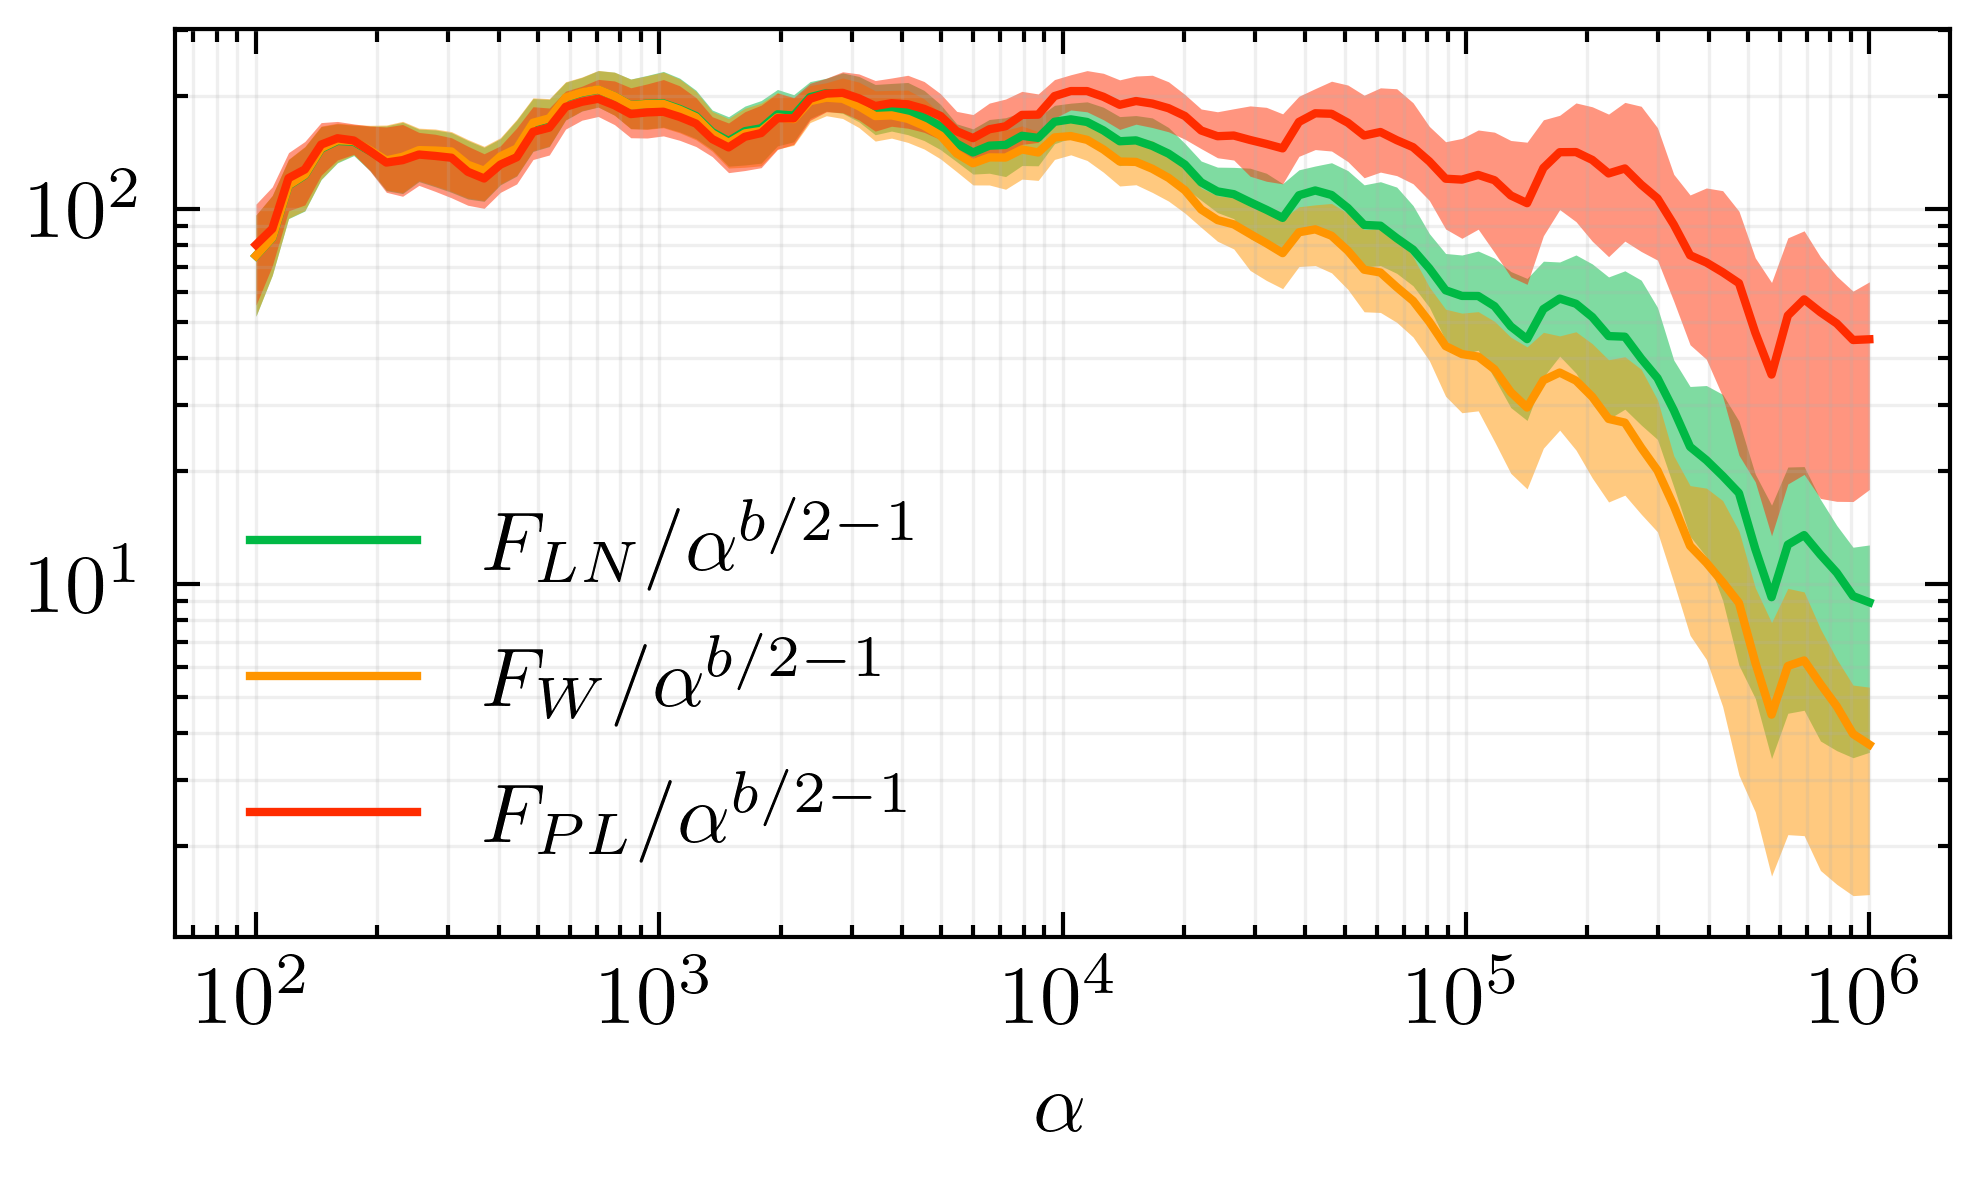

In [ ]:
tilt = alphas ** (- q - 1)
 
for fit, params, fit_name, fit_c in zip(
    [LN_fit, W_fit, PL_fit],
    [LN_fit_params, W_fit_params, PL_fit_params],
    ["LN", "W", "PL"],
    ["C1", "C2", "C3"]
    ):
    bootstrap_kde_data = np.vstack(
        [
            fit.F_norm(
                alphas,
                params,
                sm.random_S_function(np.random.default_rng(seed))
            )
        for seed in tqdm(seed_vals_to_run, desc="Computing F_norm")
        ]
        ).T 

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1) / tilt
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1) / tilt
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1) / tilt

    # 95% confidence interval
    plt.fill_between(
        alphas, lower, upper,
        alpha=0.5,
        color= fit_c,
        linewidth = 0,
        # label = r"PL $95\%$ CI"
    )

    # Mean bootstrap KsDE
    plt.plot(alphas, mean_pdf, label = rf"$F_{{{fit_name}}} / \alpha^{{b/2 - 1}}$", c = fit_c)

# plt.plot(alphas, )
# plt.ylim(1e-11, counts.max() * 10)
# plt.xlim(200, LN_fit.plot_range[1] * (1/0.7))
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
# plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig(".plots/all_fits_tilted.png")
plt.show()